> **Note:** Key findings from this notebook (BUG-018, age-$m$ misalignment, burn-in convergence) are summarized in `history/20260404-TM-nonlinear-functionals-summary.md` and `BUGS_private/HAFiscal_BUG-018_tm_init_pLvl_Urate_mismatch.md`.

# Why TM-init burn-in does not deliver an ergodic `pLvl` distribution

This notebook focuses on **permanent income** (`pLvl`) in the **TM ergodic draw + synthetic `pLvl` + inner `sim_one_period` burn-in** pipeline (`verify_four_methods_agreement._mc_burnin_tm_init` and the same pattern in `test_asymptotic_equality_revised`, `Simulate.py`, etc.).

**Symptom:** During burn-in, **mean `pLvl` often drifts** even though **market resources and Markov employment** were drawn from the TM stationary distribution on `(m,j)`.

**Core structural points (developed below):**

1. **The TM is built on `(m,j)` only.** Stationarity is for the marginal of normalized wealth × employment. **`pLvl` is not a state of that TM.**

2. **Production TM-init (after BUG-018)** uses `u_{TM}` / `u_{\text{ergodic}}` from the same baseline TM as the `(m,j)` draw for `g` and shock-variance scaling. **Remaining gap:** `p` is still drawn **independently** of the realized `j` used for `(m,j)` (not the **joint** stationary draw), and ages are **i.i.d.** from the survival law rather than tied to the TM age structure.

3. **Simulation couples `pLvl` to `j` each period** (employed vs unemployed growth differs under SST). An initial cross-section whose **level of `p` is independent of `j`** cannot be a draw from the **joint** stationary distribution of the MC unless that joint happens to factorize (it generally does not).

4. **`compute_pLvl_distribution` / `compute_analytical_mean_pLvl` in `tm_methods.py`** describe the **marginal ergodic of `p` under the analytical age–cohort construction** (used for TM aggregation). The init recipe is only an **approximation** to that marginal, and it still **does not** fix the **joint** \((p,m,j)\).

**Companion:** `Gatekeeper_Asymptotic_Equality.ipynb` (burn-in traces), `history/20260331-mathematical-derivations-harmenberg.md` (when the joint distribution matters).

**Why you might see “no drift” here but a visible trend in Gatekeeper**

- The inner routine is the same: `_mc_burnin_tm_init` in `verify_four_methods_agreement.py`. Gatekeeper calls it with **`warmup=24`** (and typically **`agents=20_000`** in that notebook). Here we often use **more agents (e.g. 50k)** for smoother cross-sectional statistics while keeping **one education type**. The burn-in trace’s **`mean_pLvl` is taken from the usual `state_now` path**; for the same seed and agent count it matches **`AggFiscalType` with `use_dual=False`** (the dual flag only copies init into `state_now_Q`).
- **All quantitative cells use a single education group** (high school) via `_build_single_type_economy` — not the paper’s weighted mix of three groups — so runs stay interpretable and faster.
- This notebook defaults to **`N=50_000`** agents (raise or lower if needed) and **`WARMUP=48`** for the main drift panels. A longer horizon and a different simulated cross-section often make **net** mean `pLvl` at the **last** step close to the **first** even when the path still **moves** in between (compare max−min on the series, not only endpoints).
- Here, **`u_tm` from the TM ergodic equals `Urate_normal`**, so the two analytical **`E[p]`** lines coincide — the “% vs `E[p|u_tm]`” panel stays near **zero**, which can look like “no bug” even when dynamics are still re-sorting the joint `(p,j)`.
- So this is **not** evidence that a recent code change “fixed” the ergodic-gap issue; it is mostly **scale, horizon, and calibration alignment**. The structural points above still stand: **`pLvl` is not a TM state**, and the init recipe does not draw the **joint** stationary distribution of the Monte Carlo.

## What this notebook tries to quantify

1. **Mean `pLvl` vs a simulated steady state.** After TM init, how many inner `sim_one_period` steps until the cross-sectional **mean** `pLvl` is close to the mean in a **long** continuation of the **same** MC (TM init → many periods)? The analytical `E[p|u_tm]` line is a useful *TM-consistent scale check* but it is **not** the same object as the **long-run MC mean** under simultaneous \((p,m,j)\) dynamics.

2. **Joint \((m_{\mathrm{Nrm}}, p_{\mathrm{lvl}})\) vs that simulated steady state.** We use a **2D histogram** of \((\log m_{\mathrm{Nrm}}, \log p_{\mathrm{lvl}})\) pooled over the **last** windows of a long reference run, then track **total-variation (half L1) distance** to that reference as burn-in proceeds. Same **90% gap-closure** construction as in the marginal-\(\log p\) section below.

3. **Complementary marginal-\(\log p\) vs `compute_pLvl_distribution`:** the section *“How long … on the `log(pLvl)` marginal?”* compares the simulated \(\log p\) histogram to the **TM analytical mixture** — informative for the **discrete-\(p\)** story, **not** a full joint steady state.

**Saved outputs in git:** The plots and stdout below are meant to match an in-place execution (same as “Run All” in Jupyter). From `Code/HA-Models`:
`MPLBACKEND=Agg uv run jupyter nbconvert --to notebook --execute pLvl_TM_init_ergodic_gap.ipynb --inplace`
Using `--output /tmp/...` only updates a copy under `/tmp`, not this file.


## Drift: what it is **not** vs what it **is**

**Not the explanation:** This notebook is **not** comparing an ergodic for `pLvl` that “includes recessions probabilistically” to a simulation that **never** recesses. The baseline TM, `u_ergodic`, `E[pLvl]`, and inner burn-in all use the **same non-recession (`base`) calibration**: `build_tm_agg_fiscal` / `compute_baseline_tm_data` work off the agent’s **normal-times** micro chain and policies (`MrkvArray[0]`, `cFunc[j]` at macro 0), not a mixture over recession macro paths.

**What actually moves mean `pLvl`:** (1) **`pLvl` is not a state of the `(m,j)` TM** — the draw for levels of `p` is only a **marginal recipe**, not the **joint** stationary distribution of the full Monte Carlo with `(p,m,j)` evolving together. (2) **`sim_one_period` couples `p` to `j` every period**, so the cross-section **re-sorts** after init even when the **employment share** was already drawn from the TM. (3) **Finite `N` and short warmup** turn that joint adjustment into a **visible trend** or **path wiggle** in mean `p` (especially in the Gatekeeper-like panel), not necessarily a big net change by the last step when `N` is large and warmup is long.

A recession-vs-no-recession mismatch would be a **different** experiment (e.g. TM from `base` but MC on a recession path, or `E[p]` from a recession-inclusive object while simulating only normal times).

In [1]:
# Setup: path, argv guard, single-type economy (Reduced_Run, high school)
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

_HERE = Path.cwd().resolve()
REPO_ROOT = _HERE
for _ in range(10):
    if (REPO_ROOT / "Code" / "HA-Models" / "FromPandemicCode" / "AggFiscalModel.py").is_file():
        break
    REPO_ROOT = REPO_ROOT.parent
else:
    REPO_ROOT = _HERE

_FPC = REPO_ROOT / "Code" / "HA-Models" / "FromPandemicCode"
os.chdir(_FPC)
for pth in (_FPC, _FPC.parent):
    if str(pth) not in sys.path:
        sys.path.insert(0, str(pth))

_orig_argv = sys.argv[:]
sys.argv = [sys.argv[0], "1.01", "2.0", "0.7"]

from AggFiscalModel import AggFiscalType
from income_process_sst import effective_pLvl_growth, effective_perm_shock_variance_periods
from tm_methods import (
    compute_analytical_mean_pLvl,
    compute_baseline_tm_data,
    compute_pLvl_distribution,
    find_ergodic_distribution,
)
from verify_four_methods_agreement import _build_single_type_economy, _mc_burnin_tm_init

sys.argv = _orig_argv

RNG_SEED = 42
# Single education group only (high school) — faster than multi-type; see _build_single_type_economy.
N = 50_000
WARMUP = 48
MCOUNT = 100

economy, _base_dict = _build_single_type_economy(
    educ="highschool",
    agent_count=N,
    seed=RNG_SEED,
    act_T=100,
    agent_cls=AggFiscalType,
)
economy.solve()
agent = economy.agents[0]
J = int(agent.num_base_MrkvStates)
M = int(agent.T_age)

u_cal = float(getattr(agent, "Urate_normal", 0.0))
print(f"N={N}, J={J}, T_age={M}, Urate_normal={u_cal:.6f}")


/home/shared/github/llorracc/HAFiscal-Latest/.venv/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


EducationGroup:  0 , betaDistr : [0.4827, 0.5674, 0.6521, 0.7368, 0.8215, 0.9062, 0.9909]
EducationGroup:  1 , betaDistr : [0.858, 0.8803, 0.9025, 0.9248, 0.947, 0.9693, 0.9904]
EducationGroup:  2 , betaDistr : [0.9695, 0.9737, 0.9779, 0.9821, 0.9863, 0.9905, 0.9947]
CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]


N=50000, J=4, T_age=100, Urate_normal=0.044000


In [2]:
# TM ergodic unemployment vs calibration; growth factors and E[pLvl]
bd = compute_baseline_tm_data(economy, mCount=MCOUNT, verbose=False)[0]
erg = np.asarray(bd["ergodic"], dtype=float).ravel()
dist_m = bd["dist_mGrid"]
Mgrid = len(dist_m)
erg_emp_mass = float(np.sum(erg[:Mgrid]))
u_tm = 1.0 - erg_emp_mass

g_cal = effective_pLvl_growth(agent, u_cal)
g_tm = effective_pLvl_growth(agent, u_tm)

E_p_tm = compute_analytical_mean_pLvl(agent, unemployment_rate=u_tm)
E_p_cal = compute_analytical_mean_pLvl(agent, unemployment_rate=u_cal)
E_p_tm_method = float(bd["E_pLvl"])

print(f"u from TM ergodic (1 - mass on employed m-slice): {u_tm:.6f}")
print(f"Urate_normal (calibration):                      {u_cal:.6f}")
print(f"g = effective_pLvl_growth with u_tm:  {g_tm:.8f}")
print(f"g = effective_pLvl_growth with u_cal: {g_cal:.8f}")
print(f"E[pLvl] analytical, u_tm:  {E_p_tm:.6f}")
print(f"E[pLvl] analytical, u_cal: {E_p_cal:.6f}")
print(f"E[pLvl] in baseline_tm_data: {E_p_tm_method:.6f}")

u from TM ergodic (1 - mass on employed m-slice): 0.044000
Urate_normal (calibration):                      0.044000
g = effective_pLvl_growth with u_tm:  1.00433068
g = effective_pLvl_growth with u_cal: 1.00433068
E[pLvl] analytical, u_tm:  14.859357
E[pLvl] analytical, u_cal: 14.859357
E[pLvl] in baseline_tm_data: 14.859357


In [3]:
# Replicate synthetic pLvl draw (same algebra as _mc_burnin_tm_init after BUG-018)


def draw_synthetic_plvl_tm_init(agent, n, rng, u_unemp):
    """Match `_mc_burnin_tm_init`: use TM-aligned unemployment rate for g and shock variance."""
    pLogMean = agent.pLogInitMean
    pLogStd = getattr(agent, "pLogInitStd", getattr(agent, "pLvlInitStd", 0.0))
    PermShkDstn_0 = agent.IncShkDstn_base[0][0]
    log_ps = np.log(PermShkDstn_0.atoms[0])
    ps_var = float(
        np.dot(PermShkDstn_0.pmv, log_ps**2)
        - np.dot(PermShkDstn_0.pmv, log_ps) ** 2
    )
    g_lvl = effective_pLvl_growth(agent, u_unemp)
    L = float(agent.LivPrb[0][0])
    T_ag = int(agent.T_age)
    age_probs = np.array([L ** (k - 1) for k in range(1, T_ag + 1)], dtype=float)
    age_probs /= np.sum(age_probs)
    ages = rng.choice(T_ag, size=n, p=age_probs) + 1
    eff_emp = effective_perm_shock_variance_periods(ages, agent, u_unemp)
    log_p = rng.normal(pLogMean, pLogStd, n)
    log_p += ages * np.log(g_lvl)
    log_p += eff_emp * (-ps_var / 2.0)
    log_p += rng.normal(0.0, np.sqrt(ps_var * eff_emp))
    return np.exp(log_p), ages


rng = np.random.RandomState(RNG_SEED)
p_syn, ages_syn = draw_synthetic_plvl_tm_init(agent, N, rng, u_tm)

print(f"Mean synthetic pLvl: {np.mean(p_syn):.6f}")
print(f"  vs E[p|u_tm]  (target for TM scaling): {E_p_tm:.6f}")
print(f"  vs E[p|u_cal] (what u_cal mixture implies): {E_p_cal:.6f}")
print(f"Relative gap vs u_tm target: {100*(np.mean(p_syn)/E_p_tm - 1):.4f} %")

Mean synthetic pLvl: 14.907705
  vs E[p|u_tm]  (target for TM scaling): 14.859357
  vs E[p|u_cal] (what u_cal mixture implies): 14.859357
Relative gap vs u_tm target: 0.3254 %


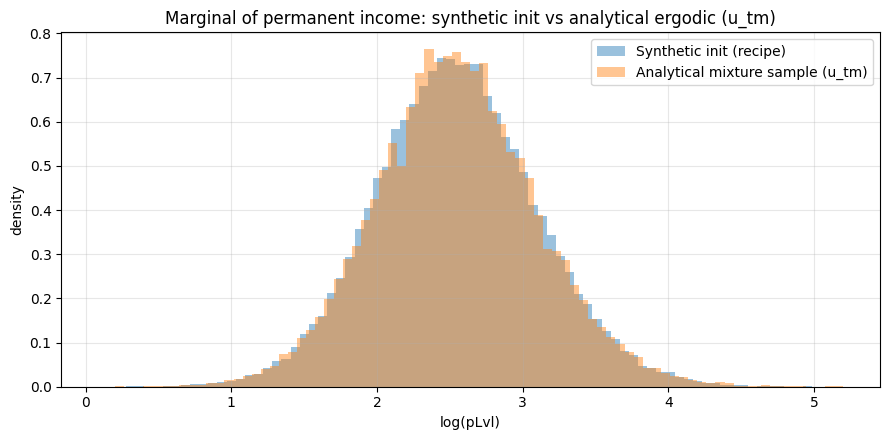

In [4]:
# Marginal of log(p): synthetic draw vs analytical discrete mixture (u_tm)
p_grid, w = compute_pLvl_distribution(agent, n_points=600, unemployment_rate=u_tm)
# Sample from discrete approximation for smooth KDE comparison
rng2 = np.random.RandomState(RNG_SEED + 1)
idx = rng2.choice(len(p_grid), size=min(200_000, 50 * len(p_grid)), p=w)
p_ref = p_grid[idx]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(np.log(p_syn), bins=80, density=True, alpha=0.45, label="Synthetic init (recipe)")
ax.hist(np.log(p_ref), bins=80, density=True, alpha=0.45, label="Analytical mixture sample (u_tm)")
ax.set_xlabel("log(pLvl)")
ax.set_ylabel("density")
ax.set_title("Marginal of permanent income: synthetic init vs analytical ergodic (u_tm)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

Corr(log p, micro state index) at synthetic init: 0.005789 (≈0 if independent)


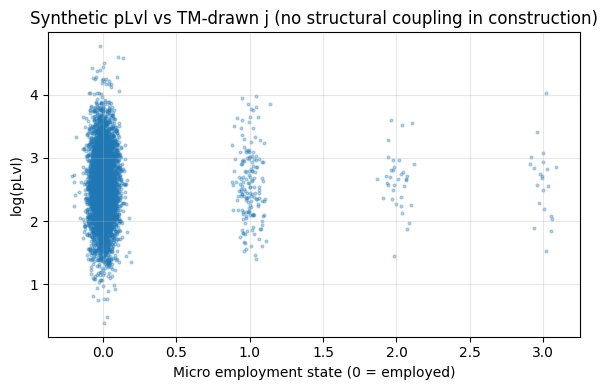

In [5]:
# Independence of pLvl from employment at init vs coupling under dynamics
# Draw TM (m,j) same as burn-in (simplified: use ergodic on grid)
bd = compute_baseline_tm_data(economy, mCount=MCOUNT, verbose=False)[0]
erg = np.asarray(bd["ergodic"], dtype=float).ravel()
erg /= erg.sum()
dist_m = bd["dist_mGrid"]
Mgrid = len(dist_m)
rng3 = np.random.RandomState(RNG_SEED + 2)
bins = rng3.choice(len(erg), size=N, p=erg)
j_draw = bins // Mgrid
p_draw, _ = draw_synthetic_plvl_tm_init(agent, N, rng3, u_tm)

micro = j_draw % J
corr = np.corrcoef(np.log(p_draw).astype(float), micro.astype(float))[0, 1]
print(f"Corr(log p, micro state index) at synthetic init: {corr:.6f} (≈0 if independent)")

stride = max(1, N // 5000)
ix = np.arange(0, N, stride)
jitter = 0.05 * rng3.standard_normal(len(ix))

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(
    micro[ix].astype(float) + jitter,
    np.log(p_draw[ix]),
    s=4,
    alpha=0.3,
)
ax.set_xlabel("Micro employment state (0 = employed)")
ax.set_ylabel("log(pLvl)")
ax.set_title("Synthetic pLvl vs TM-drawn j (no structural coupling in construction)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

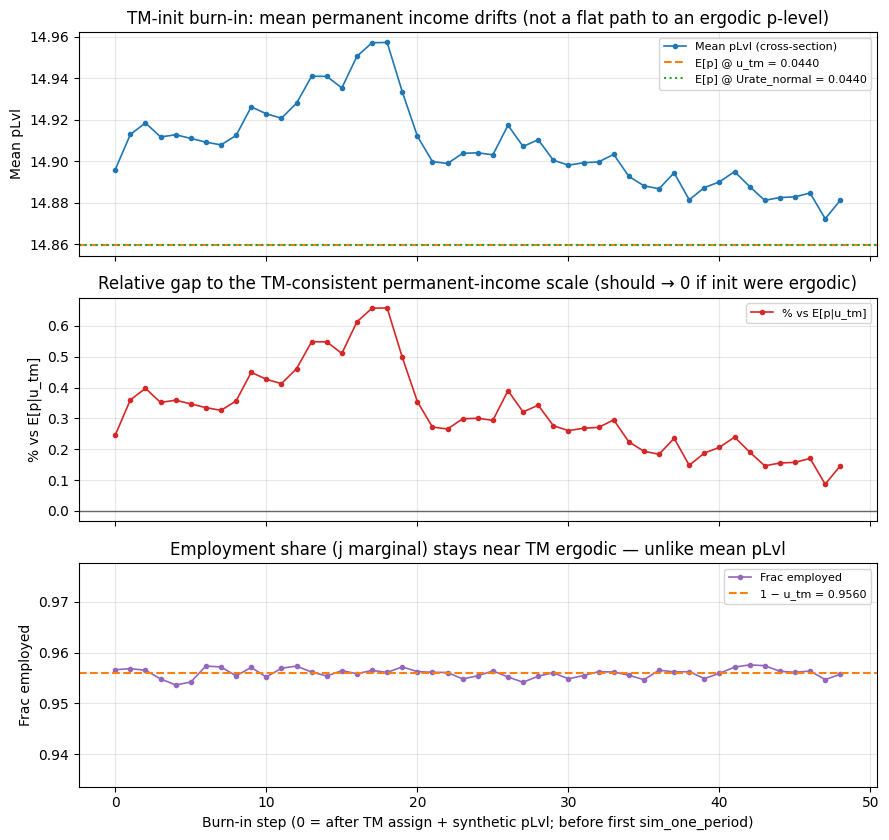

Mean pLvl: step 0 -> 48: 14.895939 -> 14.881117 (Δ = +0.014822)
% vs E[p|u_tm]: step 0 -> 48: +0.2462 -> +0.1464 (Δ = -0.0997 pp)


In [6]:
# Burn-in “problem” in one figure: pLvl trends while employment share stays near ergodic
trace = _mc_burnin_tm_init(
    economy,
    warmup=WARMUP,
    neutral_measure=True,
    use_dual=False,
    record_trace=True,
)
steps = trace["step"]
mean_p = trace["mean_pLvl"]
frac_e = trace["frac_employed"]
target_frac_emp = 1.0 - u_tm

pct_vs_tm = 100.0 * (mean_p / E_p_tm - 1.0)

fig, axes = plt.subplots(3, 1, figsize=(9, 8.5), sharex=True)
ax1, ax2, ax3 = axes

ax1.plot(steps, mean_p, marker="o", ms=3, lw=1.2, color="C0", label="Mean pLvl (cross-section)")
ax1.axhline(E_p_tm, color="C1", ls="--", lw=1.5, label=f"E[p] @ u_tm = {u_tm:.4f}")
ax1.axhline(E_p_cal, color="C2", ls=":", lw=1.5, label=f"E[p] @ Urate_normal = {u_cal:.4f}")
ax1.set_ylabel("Mean pLvl")
ax1.set_title(
    "TM-init burn-in: mean permanent income drifts (not a flat path to an ergodic p-level)"
)
ax1.legend(loc="best", fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.axhline(0.0, color="0.4", ls="-", lw=1)
ax2.plot(steps, pct_vs_tm, marker="o", ms=3, lw=1.2, color="C3", label="% vs E[p|u_tm]")
ax2.set_ylabel("% vs E[p|u_tm]")
ax2.set_title("Relative gap to the TM-consistent permanent-income scale (should → 0 if init were ergodic)")
ax2.legend(loc="best", fontsize=8)
ax2.grid(True, alpha=0.3)

ax3.plot(steps, frac_e, marker="o", ms=3, lw=1.2, color="C4", label="Frac employed")
ax3.axhline(target_frac_emp, color="C1", ls="--", lw=1.5, label=f"1 − u_tm = {target_frac_emp:.4f}")
ax3.set_xlabel("Burn-in step (0 = after TM assign + synthetic pLvl; before first sim_one_period)")
ax3.set_ylabel("Frac employed")
ax3.set_title("Employment share (j marginal) stays near TM ergodic — unlike mean pLvl")
ax3.legend(loc="best", fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(max(0.0, float(np.min(frac_e)) - 0.02), min(1.0, float(np.max(frac_e)) + 0.02))

fig.tight_layout()
plt.show()

d0, d1 = float(mean_p[0] - mean_p[-1]), float(pct_vs_tm[-1] - pct_vs_tm[0])
print(f"Mean pLvl: step 0 -> {WARMUP}: {mean_p[0]:.6f} -> {mean_p[-1]:.6f} (Δ = {d0:+.6f})")
print(f"% vs E[p|u_tm]: step 0 -> {WARMUP}: {pct_vs_tm[0]:+.4f} -> {pct_vs_tm[-1]:+.4f} (Δ = {d1:+.4f} pp)")

### Gatekeeper-aligned warmup (single education type)

Same `_mc_burnin_tm_init` and **`warmup=24`** as `GATEKEEPER_PARAMS` in `Gatekeeper_Asymptotic_Equality.ipynb`. **`N_GK`** is set to **50_000** here (Gatekeeper often uses 20_000) so MC noise is lower while still using **one education group** only.

CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]


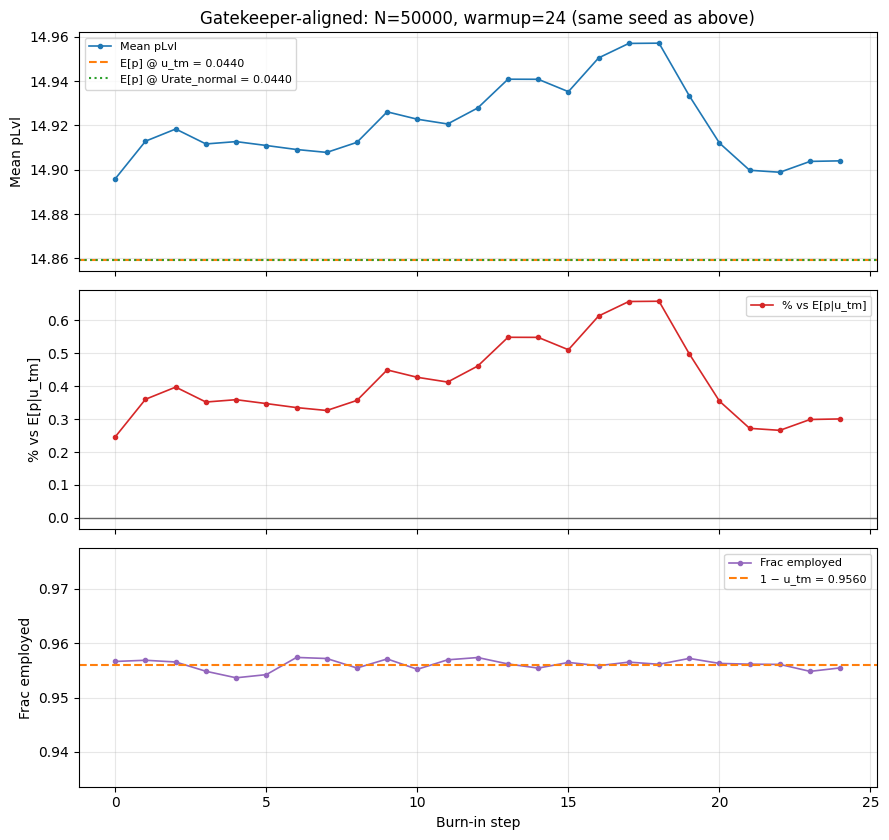

Net step0→end mean pLvl: +0.0542 %   (path range / mean: 0.4104 %)


In [7]:
# Same inner warmup as Gatekeeper; larger N than Gatekeeper’s 20k for lower MC noise in this notebook.
N_GK, W_GK = 50_000, 24
economy_gk, _ = _build_single_type_economy(
    educ="highschool",
    agent_count=N_GK,
    seed=RNG_SEED,
    act_T=100,
    agent_cls=AggFiscalType,
)
economy_gk.solve()
agent_gk = economy_gk.agents[0]
bd_gk = compute_baseline_tm_data(economy_gk, mCount=MCOUNT, verbose=False)[0]
erg_gk = np.asarray(bd_gk["ergodic"], dtype=float).ravel()
Mgrid_gk = len(bd_gk["dist_mGrid"])
u_tm_gk = 1.0 - float(np.sum(erg_gk[:Mgrid_gk]))
u_cal_gk = float(getattr(agent_gk, "Urate_normal", 0.0))
E_p_tm_gk = compute_analytical_mean_pLvl(agent_gk, unemployment_rate=u_tm_gk)
E_p_cal_gk = compute_analytical_mean_pLvl(agent_gk, unemployment_rate=u_cal_gk)

trace_gk = _mc_burnin_tm_init(
    economy_gk,
    warmup=W_GK,
    neutral_measure=True,
    use_dual=False,
    record_trace=True,
)
steps_gk = trace_gk["step"]
mean_pg = trace_gk["mean_pLvl"]
frac_eg = trace_gk["frac_employed"]
pct_gk = 100.0 * (mean_pg / E_p_tm_gk - 1.0)

fig, axes = plt.subplots(3, 1, figsize=(9, 8.5), sharex=True)
ax1, ax2, ax3 = axes

ax1.plot(steps_gk, mean_pg, marker="o", ms=3, lw=1.2, color="C0", label="Mean pLvl")
ax1.axhline(E_p_tm_gk, color="C1", ls="--", lw=1.5, label=f"E[p] @ u_tm = {u_tm_gk:.4f}")
ax1.axhline(E_p_cal_gk, color="C2", ls=":", lw=1.5, label=f"E[p] @ Urate_normal = {u_cal_gk:.4f}")
ax1.set_ylabel("Mean pLvl")
ax1.set_title(f"Gatekeeper-aligned: N={N_GK}, warmup={W_GK} (same seed as above)")
ax1.legend(loc="best", fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.axhline(0.0, color="0.4", ls="-", lw=1)
ax2.plot(steps_gk, pct_gk, marker="o", ms=3, lw=1.2, color="C3", label="% vs E[p|u_tm]")
ax2.set_ylabel("% vs E[p|u_tm]")
ax2.legend(loc="best", fontsize=8)
ax2.grid(True, alpha=0.3)

ax3.plot(steps_gk, frac_eg, marker="o", ms=3, lw=1.2, color="C4", label="Frac employed")
ax3.axhline(1.0 - u_tm_gk, color="C1", ls="--", lw=1.5, label=f"1 − u_tm = {1.0 - u_tm_gk:.4f}")
ax3.set_xlabel("Burn-in step")
ax3.set_ylabel("Frac employed")
ax3.legend(loc="best", fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(max(0.0, float(np.min(frac_eg)) - 0.02), min(1.0, float(np.max(frac_eg)) + 0.02))

fig.tight_layout()
plt.show()

rel_end = 100.0 * (float(mean_pg[-1]) - float(mean_pg[0])) / float(mean_pg[0])
rng_pct = 100.0 * (float(np.max(mean_pg)) - float(np.min(mean_pg))) / float(np.mean(mean_pg))
print(f"Net step0→end mean pLvl: {rel_end:+.4f} %   (path range / mean: {rng_pct:.4f} %)")

## How long a burn-in for **mean `pLvl`** and the **joint** \((m_{\mathrm{Nrm}}, p_{\mathrm{lvl}})\) vs **simulated** steady state?

**Reference (operational definition of “steady state” here):** one MC run with TM init (`warmup=0`), then **`T_REF`** further `sim_one_period` steps. Pool cross sections from the **last `W_REF`** of those steps (all agents) to form:
- a **reference mean** \(\bar p_{\mathrm{ref}}\)
- a **reference 2D histogram** \(\hat H_{\mathrm{ref}}\) on \((\log m_{\mathrm{Nrm}}, \log p_{\mathrm{lvl}})\) (fixed bin edges from that pooled sample)

**Metrics after TM init at simulated time \(t\):**
- **Mean level:** \(r(t)=|\mathbb{E}[p]_t-\bar p_{\mathrm{ref}}|/\bar p_{\mathrm{ref}}\). Let \(r_\infty\) be the minimum of \(r(t)\) over the **tail** \([T_{\max}-T_{\mathrm{tail}},\,T_{\max}]\) (finite-\(N\) floor). **Gap-closed fraction** \(F_r(t)=(r(0)-r(t))/(r(0)-r_\infty)\). Report first \(t\) with \(F_r(t)\geq 0.9\).
- **Joint:** same construction with \(D_{\mathrm{joint}}(t)=\tfrac12\sum_{k}|\hat H_t(k)-\hat H_{\mathrm{ref}}(k)|\) (TV / half L1 on the **flattened** normalized 2D histogram).

We sweep **several seeds**; distributions of \(t_{0.9}\) summarize reliability. **Scope:** **one education group** (high school) and **`N_MC`** agents (default **50_000**). **Caveats:** the reference is **path- and seed-dependent**; raise `T_REF` and `W_REF` for a stricter anchor. This does **not** prove convergence to a unique ergodic law — it measures distance to **one long forward simulation** from TM init, which is the practical target for how much inner burn-in is enough.
**Implementation note:** `mNrm` in `state_now` is **not** yet valid immediately after `_mc_burnin_tm_init` (all NaN until the first `sim_one_period`). The **joint** histogram and its \(t_{0.9}\) therefore start at **step \(\geq 1\)**; **mean-\(p\)** uses step 0 (synthetic `pLvl` is set at TM init).


Building MC reference (TM init + long forward)...
  (mNrm is NaN right after TM init; reference uses post-sim cross sections only.)
CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]


  ref mean pLvl (pooled last 25 of 100 steps): 14.861608
  compare E[p|u_tm] analytical: 14.859357
CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]


CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]


CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]


CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]


CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]


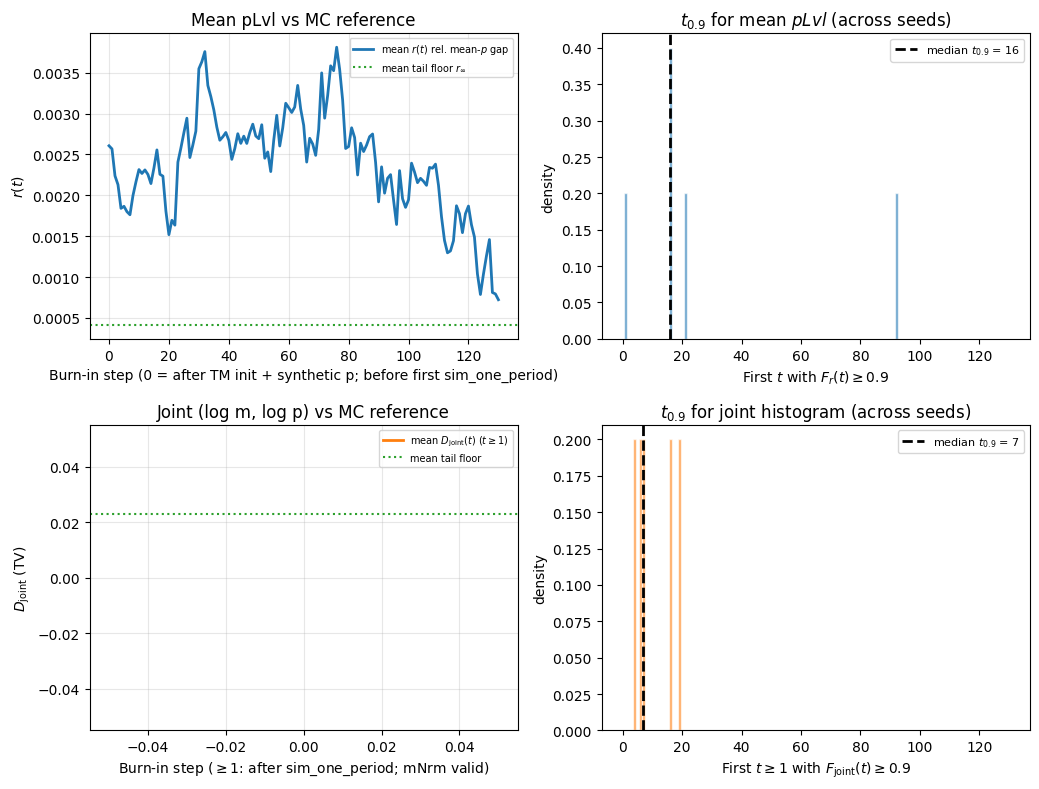

N_MC=50000, T_REF=100, W_REF=25, T_MAX=130, TAIL=32, JOINT_BINS=16, seeds=5
Reference mean pLvl: 14.861608
Cross-seed average relative mean-p gap r(t)=|E[p]_t - p_ref|/p_ref at selected t:
  t=  0:  r(t) = 0.002606
  t= 12:  r(t) = 0.002311
  t= 24:  r(t) = 0.002579
  t= 48:  r(t) = 0.002870
  t= 72:  r(t) = 0.002944
  t= 96:  r(t) = 0.001643
  t=120:  r(t) = 0.001869
  t=130:  r(t) = 0.000723
Mean p:  t_0.9 median=16.0  Q1=16.0  Q3=21.0
Joint:   t_0.9 median=7.0  Q1=6.0  Q3=16.0
Share mean t_90<=24: 0.80  <=48: 0.80  | joint <=24: 1.00  <=48: 1.00

**Conclusion:** Compare median t_0.9 above to your inner warmup (e.g. 24 in Gatekeeper). If median t_0.9 equals T_MAX below, the run is censored — increase T_MAX and re-execute.


In [8]:
# --- Mean pLvl + joint (log m, log p) vs long MC reference; multi-seed t_0.9 ---
# Requires: setup + economy solved (`agent`, `MCOUNT`).

from copy import deepcopy

# Reference run (single long chain)
N_MC = 50_000  # single education group; large N for stable histograms / mean-p gaps
T_REF = 100
W_REF = 25
T_MAX = 130  # must exceed median t_0.9 or printed recommendation is censored
TAIL = 32
N_SEEDS_MC = 5
JOINT_BINS = 16
REF_SEED = 9_999

bd_mc = compute_baseline_tm_data(economy, mCount=MCOUNT, verbose=False)[0]
erg_mc = np.asarray(bd_mc["ergodic"], dtype=float).ravel()
Mgrid_mc = len(bd_mc["dist_mGrid"])
u_tm_mc = 1.0 - float(np.sum(erg_mc[:Mgrid_mc]))


def _finite_mp(ag):
    m = np.asarray(ag.state_now.get("mNrm"), dtype=float)
    p = np.asarray(ag.state_now["pLvl"], dtype=float)
    ok = np.isfinite(m) & np.isfinite(p) & (m > 0) & (p > 0)
    return m[ok], p[ok]


def _pool_last_windows(ag, n_periods, window):
    lm_list, lp_list = [], []
    for _t in range(n_periods):
        ag.sim_one_period()
        m, p = _finite_mp(ag)
        lm_list.append(np.log(m))
        lp_list.append(np.log(p))
    sl = slice(-window, None)
    lm = np.concatenate(lm_list[sl], axis=0)
    lp = np.concatenate(lp_list[sl], axis=0)
    return lm, lp


def _edges_from_sample(lm, lp, n_bins):
    lo_m, hi_m = np.percentile(lm, [0.5, 99.5])
    lo_p, hi_p = np.percentile(lp, [0.5, 99.5])
    pad_m = 0.02 * max(hi_m - lo_m, 1e-6)
    pad_p = 0.02 * max(hi_p - lo_p, 1e-6)
    e_m = np.linspace(lo_m - pad_m, hi_m + pad_m, n_bins + 1)
    e_p = np.linspace(lo_p - pad_p, hi_p + pad_p, n_bins + 1)
    return e_m, e_p


def _hist2d_norm(lm, lp, e_m, e_p):
    H, _, _ = np.histogram2d(lm, lp, bins=[e_m, e_p])
    H = H.astype(float).ravel()
    s = float(H.sum())
    return (H / s) if s > 0 else H


def _tv(h1, h2):
    return 0.5 * float(np.sum(np.abs(h1 - h2)))


def _build_ref():
    eco, _ = _build_single_type_economy(
        educ="highschool",
        agent_count=N_MC,
        seed=REF_SEED,
        act_T=100,
        agent_cls=AggFiscalType,
    )
    eco.solve()
    _mc_burnin_tm_init(
        eco,
        warmup=0,
        neutral_measure=True,
        use_dual=False,
        record_trace=False,
    )
    ag = eco.agents[0]
    lm, lp = _pool_last_windows(ag, T_REF, W_REF)
    mean_pref = float(np.mean(np.exp(lp)))
    e_m, e_p = _edges_from_sample(lm, lp, JOINT_BINS)
    href = _hist2d_norm(lm, lp, e_m, e_p)
    return mean_pref, href, e_m, e_p


print("Building MC reference (TM init + long forward)...")
print("  (mNrm is NaN right after TM init; reference uses post-sim cross sections only.)")
mean_pref, H_ref, edges_m, edges_p = _build_ref()
print(f"  ref mean pLvl (pooled last {W_REF} of {T_REF} steps): {mean_pref:.6f}")
print(f"  compare E[p|u_tm] analytical: {compute_analytical_mean_pLvl(agent, unemployment_rate=u_tm_mc):.6f}")

t90_mean, t90_joint = [], []
r0_list, rinf_list = [], []
d1_list, dinfj_list = [], []
R_mean_sum = np.zeros(T_MAX + 1)
D_joint_sum = np.full(T_MAX + 1, np.nan)
count_dj = np.zeros(T_MAX + 1)

for s in range(N_SEEDS_MC):
    eco_s, _ = _build_single_type_economy(
        educ="highschool",
        agent_count=N_MC,
        seed=3000 + s,
        act_T=100,
        agent_cls=AggFiscalType,
    )
    eco_s.solve()
    _mc_burnin_tm_init(
        eco_s,
        warmup=0,
        neutral_measure=True,
        use_dual=False,
        record_trace=False,
    )
    ag = eco_s.agents[0]

    r_track = np.zeros(T_MAX + 1)
    dj_track = np.full(T_MAX + 1, np.nan)

    for t in range(T_MAX + 1):
        if t > 0:
            ag.sim_one_period()
        p_lvl_all = np.asarray(ag.state_now["pLvl"], dtype=float)
        mean_p = float(np.mean(p_lvl_all))
        r_track[t] = abs(mean_p - mean_pref) / max(mean_pref, 1e-12)
        if t > 0:
            _m, p = _finite_mp(ag)
            if _m.size > 0:
                lm = np.log(_m)
                lp = np.log(p)
                Ht = _hist2d_norm(lm, lp, edges_m, edges_p)
                dj_track[t] = _tv(Ht, H_ref)

    lo_b = max(0, T_MAX - TAIL)
    r_inf = float(np.min(r_track[lo_b : T_MAX + 1]))
    r0 = float(r_track[0])
    r0_list.append(r0)
    rinf_list.append(r_inf)
    R_mean_sum += r_track

    dj_fin = dj_track[np.isfinite(dj_track)]
    lo_j = max(1, T_MAX - TAIL)
    dj_tail = dj_track[lo_j : T_MAX + 1]
    dj_tail = dj_tail[np.isfinite(dj_tail)]
    d_inf = float(np.min(dj_tail)) if dj_tail.size else float("nan")
    d1 = float(dj_track[1]) if np.isfinite(dj_track[1]) else float("nan")
    d1_list.append(d1)
    dinfj_list.append(d_inf)
    D_joint_sum += np.nan_to_num(dj_track, nan=0.0)
    count_dj += np.isfinite(dj_track).astype(float)

    def first_t90_scalar(track, v0, v_inf, t_min=0):
        if not np.isfinite(v0) or not np.isfinite(v_inf):
            return T_MAX
        denom = max(v0 - v_inf, 1e-12)
        if denom < 1e-14:
            return t_min
        F = (v0 - track) / denom
        F = np.clip(F, 0.0, 1.0)
        hit = np.where((np.arange(len(track)) >= t_min) & (F >= 0.9))[0]
        return int(hit[0]) if len(hit) else T_MAX

    t90_mean.append(first_t90_scalar(r_track, r0, r_inf, t_min=0))
    if np.isfinite(d1) and np.isfinite(d_inf):
        t90_joint.append(first_t90_scalar(dj_track, d1, d_inf, t_min=1))
    else:
        t90_joint.append(T_MAX)

D_joint_avg = np.divide(
    D_joint_sum,
    np.maximum(count_dj, 1.0),
    out=np.full_like(D_joint_sum, np.nan),
    where=count_dj > 0,
)

t90_mean = np.asarray(t90_mean, dtype=float)
t90_joint = np.asarray(t90_joint, dtype=float)
R_mean_avg = R_mean_sum / N_SEEDS_MC

fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.0))

ax = axes[0, 0]
ax.plot(np.arange(T_MAX + 1), R_mean_avg, color="C0", lw=2, label=r"mean $r(t)$ rel. mean-$p$ gap")
ax.axhline(np.mean(rinf_list), color="C2", ls=":", lw=1.5, label=r"mean tail floor $r_\infty$")
ax.set_xlabel("Burn-in step (0 = after TM init + synthetic p; before first sim_one_period)")
ax.set_ylabel(r"$r(t)$")
ax.set_title("Mean pLvl vs MC reference")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.hist(t90_mean, bins=np.arange(-0.5, T_MAX + 1.5, 1), density=True, color="C0", alpha=0.65, edgecolor="white")
ax.axvline(np.median(t90_mean), color="k", ls="--", lw=2, label=f"median $t_{{0.9}}$ = {np.median(t90_mean):.0f}")
ax.set_xlabel(r"First $t$ with $F_r(t) \geq 0.9$")
ax.set_ylabel("density")
ax.set_title(r"$t_{0.9}$ for mean $pLvl$ (across seeds)")
ax.legend(fontsize=8)

ax = axes[1, 0]
ax.plot(np.arange(T_MAX + 1), D_joint_avg, color="C1", lw=2, label=r"mean $D_{\mathrm{joint}}(t)$ ($t\geq 1$)")
ax.axhline(np.nanmean(dinfj_list), color="C2", ls=":", lw=1.5, label=r"mean tail floor")
ax.set_xlabel("Burn-in step ($\geq 1$: after sim_one_period; mNrm valid)")
ax.set_ylabel(r"$D_{\mathrm{joint}}$ (TV)")
ax.set_title("Joint (log m, log p) vs MC reference")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.hist(t90_joint, bins=np.arange(-0.5, T_MAX + 1.5, 1), density=True, color="C1", alpha=0.65, edgecolor="white")
ax.axvline(np.median(t90_joint), color="k", ls="--", lw=2, label=f"median $t_{{0.9}}$ = {np.median(t90_joint):.0f}")
ax.set_xlabel(r"First $t\geq 1$ with $F_{\mathrm{joint}}(t) \geq 0.9$")
ax.set_ylabel("density")
ax.set_title(r"$t_{0.9}$ for joint histogram (across seeds)")
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

print(f"N_MC={N_MC}, T_REF={T_REF}, W_REF={W_REF}, T_MAX={T_MAX}, TAIL={TAIL}, JOINT_BINS={JOINT_BINS}, seeds={N_SEEDS_MC}")
print(f"Reference mean pLvl: {mean_pref:.6f}")
print("Cross-seed average relative mean-p gap r(t)=|E[p]_t - p_ref|/p_ref at selected t:")
_ck = sorted(set([0, 12, 24, 48, 72, 96, 120, T_MAX]))
for _tt in _ck:
    if _tt <= T_MAX:
        print(f"  t={_tt:3d}:  r(t) = {R_mean_avg[_tt]:.6f}")
print(
    f"Mean p:  t_0.9 median={np.median(t90_mean):.1f}  Q1={np.percentile(t90_mean,25):.1f}  Q3={np.percentile(t90_mean,75):.1f}"
)
print(
    f"Joint:   t_0.9 median={np.median(t90_joint):.1f}  Q1={np.percentile(t90_joint,25):.1f}  Q3={np.percentile(t90_joint,75):.1f}"
)
print(
    f"Share mean t_90<=24: {np.mean(t90_mean<=24):.2f}  <=48: {np.mean(t90_mean<=48):.2f}  | joint <=24: {np.mean(t90_joint<=24):.2f}  <=48: {np.mean(t90_joint<=48):.2f}"
)
print(
    "\n**Conclusion:** Compare median t_0.9 above to your inner warmup (e.g. 24 in Gatekeeper). "
    "If median t_0.9 equals T_MAX below, the run is censored — increase T_MAX and re-execute."
)
if np.median(t90_mean) >= T_MAX:
    print(
        f"\n>>> CENSORED (mean pLvl): median t_0.9 = {np.median(t90_mean):.0f} >= T_MAX = {T_MAX}. "
        "No finite burn-in recommendation yet; raise T_MAX and re-run."
    )
if np.median(t90_joint) >= T_MAX - 1:
    print(
        f"\n>>> CENSORED (joint): median t_0.9 = {np.median(t90_joint):.0f} is at the horizon cap. "
        "Raise T_MAX for a clearer joint recommendation."
    )




## How long a burn-in to get most of the way on the **`log(pLvl)` marginal**?

We still do **not** have the **joint** ergodic of $(p,m,j)$. For a **focused** marginal question, fix a **reference** histogram $\\hat h_{\\mathrm{an}}$ for $\\log(p)$ from a **large i.i.d. sample** from `compute_pLvl_distribution` at **`u_tm`** (same object TM uses for the discrete $p$ marginal, not the full MC joint).

At burn-in step $t$, let $\\hat h_t$ be the cross-sectional histogram on the **same** bins. Define
$$D(t)=\\tfrac12\\sum_k\\bigl|\\hat h_t(k)-\\hat h_{\\mathrm{an}}(k)\\bigr|$$
(total variation / half L1 between histograms).

With finite $N$, you typically **cannot** drive $D(t)$ to $0$; the path **bottoms out** at a **floor** $d_{\\infty}\\approx \\min_{t\\in\\text{tail}} D(t)$ over the last segment of the run. **“90% of the way”** means the **closed fraction of the reducible gap**:
$$F(t)=\\frac{D(0)-D(t)}{D(0)-d_{\\infty}}\\in[0,1]$$
(with the denominator clipped to something positive). We report the first $t$ with $F(t)\geq 0.9$, **across seeds** (median / quartiles).

**Caveats:** $\\hat h_{\\mathrm{an}}$ matches TM’s **marginal** story, not the exact **MC** marginal at fixed $N$; the floor still mixes **sampling noise** and **model mismatch**. Increase **`N_ANALYSIS`**, **`T_MAX`**, and **`N_SEEDS`** for a stricter reading.

CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]


CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]


CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]


CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]


CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]


CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]


CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]


CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]


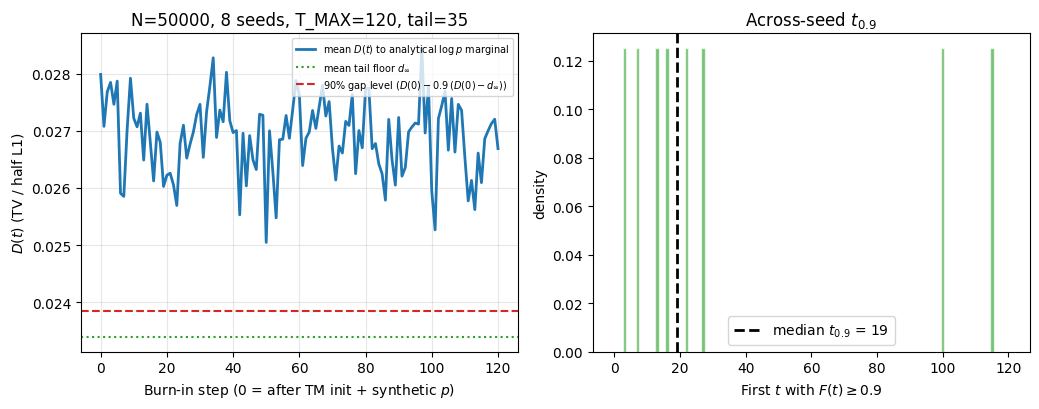

T_MAX = 120, TAIL = 35, N_BINS = 40, N = 50000, seeds = 8
mean D(0) = 0.027986   mean d_inf (tail min) = 0.023389
t_0.9: median=19.0  Q1=11.5  Q3=45.2  max=115
fraction t_90 <= 24: 0.62   <= 48: 0.75


In [9]:
# --- 90% marginal TV vs analytical ref; multi-seed t_0.9 (gap closure) ---
# Requires: setup cells above (`agent`, `u_tm`, `compute_pLvl_distribution`, ...).

N_ANALYSIS = 50_000  # single-type; large N for marginal TV stability
N_SEEDS = 8  # lower if 50k agents makes this cell too slow
T_MAX = 120  # simulation length after TM init (no warmup inside _mc_burnin)
TAIL = 35  # floor d_inf = min D(t) over t in [T_MAX - TAIL, T_MAX]
N_BINS = 40
RNG_REF = np.random.RandomState(0)

p_grid_e, w_p = compute_pLvl_distribution(agent, n_points=500, unemployment_rate=u_tm)
w_p = np.asarray(w_p, dtype=float)
w_p /= w_p.sum()
idx_e = RNG_REF.choice(len(p_grid_e), size=80_000, p=w_p)
log_s = np.log(np.maximum(np.asarray(p_grid_e[idx_e], float), 1e-16))
lo, hi = np.percentile(log_s, [0.5, 99.5])
log_edges = np.linspace(lo, hi, N_BINS + 1)

h_an, _ = np.histogram(log_s, bins=log_edges, density=False)
h_an = h_an.astype(float)
h_an /= h_an.sum()


def _logp_hist_counts(ag):
    x = np.log(np.maximum(np.asarray(ag.state_now["pLvl"], dtype=float), 1e-16))
    h, _ = np.histogram(x, bins=log_edges, density=False)
    s = float(np.sum(h))
    return (h / s) if s > 0 else h


def _hist_tv(h1, h2):
    return 0.5 * float(np.sum(np.abs(h1 - h2)))


t90_list = []
d0_list = []
dinf_list = []
D_sum = np.zeros(T_MAX + 1)
hit_no_gap = 0

for s in range(N_SEEDS):
    econ_s, _ = _build_single_type_economy(
        educ="highschool",
        agent_count=N_ANALYSIS,
        seed=1000 + s,
        act_T=100,
        agent_cls=AggFiscalType,
    )
    econ_s.solve()
    _mc_burnin_tm_init(
        econ_s,
        warmup=0,
        neutral_measure=True,
        use_dual=False,
        record_trace=False,
    )
    ag = econ_s.agents[0]
    D = np.zeros(T_MAX + 1)
    D[0] = _hist_tv(_logp_hist_counts(ag), h_an)
    for t in range(T_MAX):
        ag.sim_one_period()
        D[t + 1] = _hist_tv(_logp_hist_counts(ag), h_an)

    lo_b = max(0, T_MAX - TAIL)
    d_inf = float(np.min(D[lo_b : T_MAX + 1]))
    d0 = float(D[0])
    d0_list.append(d0)
    dinf_list.append(d_inf)
    denom = max(d0 - d_inf, 1e-12)
    F = (d0 - D) / denom
    F = np.clip(F, 0.0, 1.0)
    D_sum += D

    if d0 - d_inf < 1e-8:
        hit_no_gap += 1
        t90_list.append(0)
        continue
    hit = np.where(F >= 0.9)[0]
    t90_list.append(int(hit[0]) if len(hit) else T_MAX)

t90_arr = np.asarray(t90_list, dtype=float)
D_mean = D_sum / N_SEEDS
d0_mean = float(np.mean(d0_list))
dinf_mean = float(np.mean(dinf_list))
thr_D = d0_mean - 0.9 * max(d0_mean - dinf_mean, 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
ax = axes[0]
ax.plot(np.arange(T_MAX + 1), D_mean, color="C0", lw=2, label=r"mean $D(t)$ to analytical $\log p$ marginal")
ax.axhline(dinf_mean, color="C2", ls=":", lw=1.5, label=r"mean tail floor $d_\infty$")
ax.axhline(thr_D, color="C3", ls="--", lw=1.5, label=r"90% gap level ($D(0)-0.9\,(D(0)-d_\infty)$)")
ax.set_xlabel(r"Burn-in step (0 = after TM init + synthetic $p$)")
ax.set_ylabel(r"$D(t)$ (TV / half L1)")
ax.set_title(f"N={N_ANALYSIS}, {N_SEEDS} seeds, T_MAX={T_MAX}, tail={TAIL}")
ax.legend(fontsize=7, loc="upper right")
ax.grid(True, alpha=0.3)

ax2 = axes[1]
bins_hist = np.arange(-0.5, T_MAX + 1.5, 1.0)
ax2.hist(t90_arr, bins=bins_hist, density=True, color="C2", alpha=0.65, edgecolor="white")
ax2.axvline(np.median(t90_arr), color="k", ls="--", lw=2, label=f"median $t_{{0.9}}$ = {np.median(t90_arr):.0f}")
ax2.set_xlabel(r"First $t$ with $F(t) \geq 0.9$")
ax2.set_ylabel("density")
ax2.legend()
ax2.set_title(r"Across-seed $t_{0.9}$" + (f"  ({hit_no_gap} seeds: ~no reducible gap)" if hit_no_gap else ""))
fig.tight_layout()
plt.show()

print(f"T_MAX = {T_MAX}, TAIL = {TAIL}, N_BINS = {N_BINS}, N = {N_ANALYSIS}, seeds = {N_SEEDS}")
print(f"mean D(0) = {d0_mean:.6f}   mean d_inf (tail min) = {dinf_mean:.6f}")
print(
    f"t_0.9: median={np.median(t90_arr):.1f}  Q1={np.percentile(t90_arr, 25):.1f}  "
    f"Q3={np.percentile(t90_arr, 75):.1f}  max={np.max(t90_arr):.0f}"
)
print(f"fraction t_90 <= 24: {np.mean(t90_arr <= 24):.2f}   <= 48: {np.mean(t90_arr <= 48):.2f}")
if hit_no_gap:
    print("Note: some seeds had D(0) ≈ tail floor (little to close on this metric).")


## Takeaways

- **Unemployment rate for synthetic `p` (BUG-018, fixed in main code):** TM-init paths now use **`u_ergodic`** from `compute_baseline_tm_data` (same TM as the `(m,j)` draw) in `effective_pLvl_growth` / `effective_perm_shock_variance_periods`, matching TM `E[pLvl]`. Older diagnostics may still use **`Urate_normal`** only — see `BUGS_private/HAFiscal_BUG-018_tm_init_pLvl_Urate_mismatch.md`.

- **Marginal mismatch:** The closed-form mixture in `compute_pLvl_distribution(..., u_tm)` can differ from the **ad hoc** lognormal–with–ages draw even when means are close; the histogram cell shows distributional gaps.

- **Joint \((p,m,j)\) is wrong:** `p` is drawn **independently** of the TM draw for `j`, but **dynamics** make `p` and `j` dependent. Short burn-in cannot fully repair that mismatch — hence visible **trends in mean `pLvl`**.

- **What would be “adequate”?** A consistent joint would require either drawing **(or iterating to)** a stationary joint for the **full** MC state — e.g. long simulation from model-consistent init, or an explicit **augmented** TM that includes `p` (or a discretized `p` grid) so that the initial cross-section matches the operator’s stationary distribution.
- **Burn-in length (this notebook):** The section *“mean `pLvl` + joint … vs simulated steady state”* estimates how many steps are needed for **90% closure** of the reducible gap to a **long forward MC** reference (same TM-init protocol). The following section does the same for the **analytical** \(\log p\) marginal only — a different target.
